# Apply 1550 nm laser
work around 1556.005 to dont disturb usman
- Check variation of peak 2 and 2N against fluctuations of power
- If possible, check variation of peaks 2 and 2N against variations of training parameters
- Check variation of baseline against fluctuations of power: $\int_{\lambda_1}^{\lambda_2} d\lambda Baseline(\lambda)$


In [1]:
# Load functions
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)

    # Step 6: Apply missagh profile to waveshaper
    #gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1543.11), peak=1, phase=0, sigma=0.4)  
    #bound_gaussian1 = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1540), 8)
    #bound_gaussian2 = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1540), 7)
    #missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1550), 1e-3, bound_gaussian1, bound_gaussian2)
    #wsh.apply_profile(missagh_profile)  



def physical_model(coefficients, phases, normalization, z=1):
    N = coefficients.size(0)
    coefficients = torch.unsqueeze(coefficients,0)
    # Prepend NaN to coefficients and phases
    nan_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
    C = torch.cat((nan_tensor, coefficients), dim=1)
    k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

    intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

    # Use vectorized operations where possible
    m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
    odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
    even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

    js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
    for m in odd_m:

        valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
        j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
        term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
        intensity[:, m[0]] = term.sum(dim=1)

    for m in even_m:
        if m[0, 0] == 2 or m[0, 0] == 2 * N:
            intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
        else:
            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
            exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
            middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)
            term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
            term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)
            intensity[:, m[0]] = (term1 * term2).real
            
    return torch.abs(intensity[:, 2:2 * N + 1])

import os

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


In [2]:
# Load datasets
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import imageio  # Import the imageio library

# Step 1: Generate the make_moons dataset
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
#X, y = make_circles(n_samples=50, factor=0.5, noise=0.1, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_scaled_0_1 = (X - X_min) / (X_max - X_min)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1 = 2 * X_scaled_0_1 - 1

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_neg1_1, y, test_size=0.3, random_state=42)

# Step 4: Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   success
Applying profile...   success
Applying profile...   success
Sweep complete.


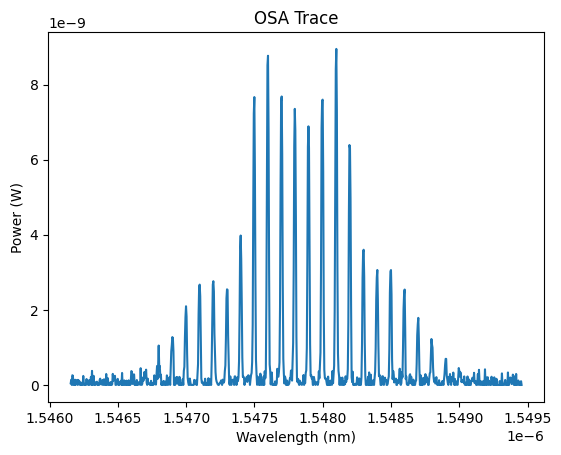

In [3]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour
from pat import make_pat_func

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

n_comblines = 15
separation_comblines = 0.2
initial_wl = 1546.005+2*0.2
# === Calibrate ===
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
peaks = np.ones(n_comblines)
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
apply_waveshaper_profile(comblines, phases, phases, channels, plot = False)
apply_waveshaper_profile(comblines, peaks, phases, channels, plot = False)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.mean(comblines))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
osa.plot_trace(wavelengths, power)

Sweep complete.
the power is 601


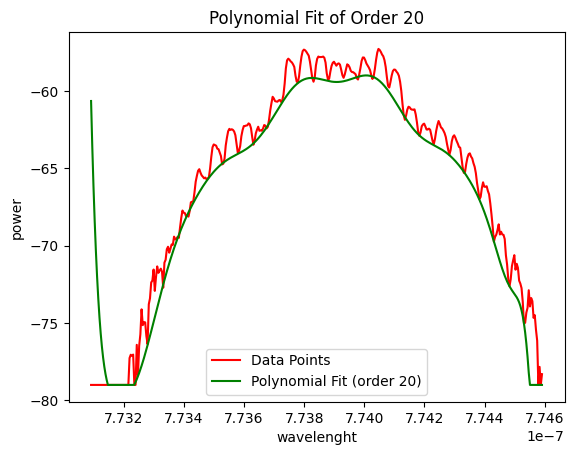

The len prominence is 376
number of maximum points 34
12.612104097954987


Text(0, 0.5, 'Amplitude')

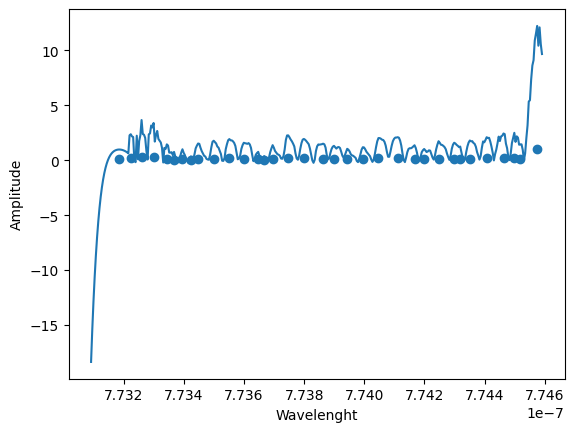

In [4]:
# Perform calibration
order = 20
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='log')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
print(f'The len prominence is {len(wavelength_trim)}')
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=20e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
normalization = 1/(fraction_max_min*max_y[0])
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')


Sweep complete.
the power is 601


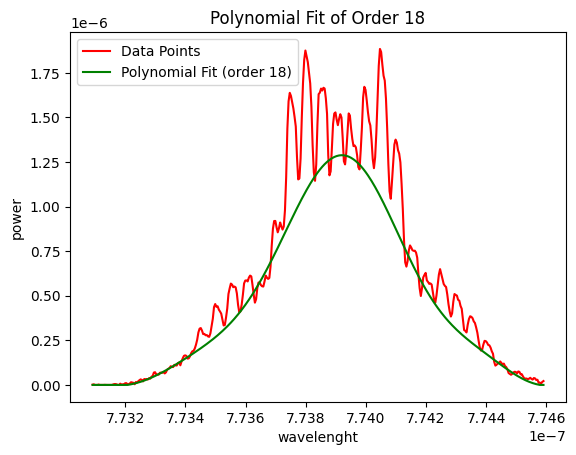

number of maximum points 30
61.367801707715195


Text(0, 0.5, 'Amplitude')

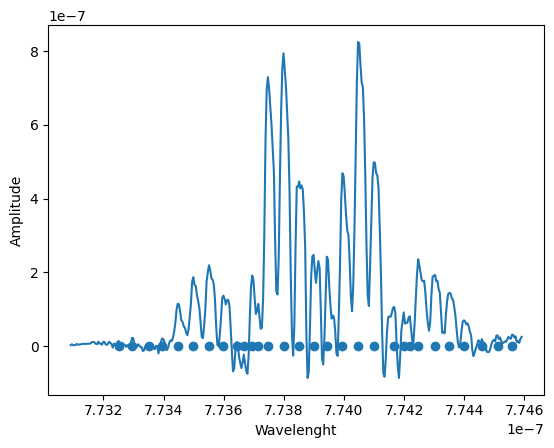

In [5]:
# Perform calibration
order = 18
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='lin')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=1e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
#normalization = 1/(fraction_max_min*max_y[0])
normalization = np.max(power)
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')

In [ ]:
# Waveshaper layer
comblines = n_comblines
#max_indices = np.arange(11,29*12,12)
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
lambda_1 = initial_wl  # Example value in nm
delta_lambda = separation_comblines  # Example value in nm
m = np.arange(1,2*comblines,1)  # Example mode number

targets = lambda_m(lambda_1, delta_lambda, m)* 1e-9
print(f"λ_m = {targets}")

wavelengths_nm = wavelength_trim 
max_indices = [np.argmin(np.abs(wavelengths_nm - t)) for t in targets]
print(f"Indices {max_indices}")

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        #self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        # Trainable phases
        self.phases = nn.Parameter(torch.zeros(len(comblines)))
        
    def forward(self, peaks, phi, normalization):    
        # Generate signal profile for each combline
        apply_waveshaper_profile(self.comblines, peaks, phi, self.channels)

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, level=0.006, sensitivity = "high1", resolution = 0.02)
        # Use scipy's find_peaks to find local maxima in the inverted signal (i.e., local minima in original)
        prominence = measurement# - self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[initrang:finrang]
        
        max_y = np.array(prominence_trim)[max_indices]
        # Convert max_y (NumPy array) back to a tensor
        max_y_tensor = (torch.tensor(max_y, dtype=torch.float32)/normalization)*10
        #print(f"The output from OSA is {torch.unsqueeze(max_y_tensor,0)}")
        return torch.unsqueeze(max_y_tensor,0)
    

λ_m = [7.73202500e-07 7.73252503e-07 7.73302513e-07 7.73352529e-07
 7.73402552e-07 7.73452581e-07 7.73502616e-07 7.73552659e-07
 7.73602707e-07 7.73652762e-07 7.73702824e-07 7.73752892e-07
 7.73802966e-07 7.73853047e-07 7.73903134e-07 7.73953228e-07
 7.74003329e-07 7.74053435e-07 7.74103549e-07 7.74153669e-07
 7.74203795e-07 7.74253928e-07 7.74304067e-07 7.74354213e-07
 7.74404365e-07 7.74454524e-07 7.74504689e-07 7.74554861e-07
 7.74605040e-07]
Indices [np.int64(28), np.int64(40), np.int64(53), np.int64(65), np.int64(78), np.int64(90), np.int64(103), np.int64(115), np.int64(128), np.int64(140), np.int64(153), np.int64(165), np.int64(178), np.int64(191), np.int64(203), np.int64(216), np.int64(228), np.int64(241), np.int64(253), np.int64(266), np.int64(278), np.int64(291), np.int64(303), np.int64(316), np.int64(328), np.int64(341), np.int64(353), np.int64(366), np.int64(375)]


In [ ]:
# Create a Model
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
channels = np.ones(n_comblines)

# Create the layer and pass input peaks
layer = WaveshaperLayer(osa, comblines=comblines, channels=channels, baseline=poly)

#this code is used to construct the PAT functions
pat_implementation = make_pat_func(layer.forward, physical_model)

# Original input dimension
input_dim = X_train.size(1)

# Desired higher dimension (replace with your desired value)
hidden_dim = n_comblines  

class ClassifierPhysical_NN_SHG(nn.Module):
    def __init__(self):
        super(ClassifierPhysical_NN_SHG, self).__init__()
        self.alpha = nn.Parameter(torch.zeros(2 * hidden_dim - 1))
        self.bias = nn.Parameter(torch.zeros(1))
        self.phases = nn.Parameter(torch.randn(len(comblines)))
        self.fc = nn.Linear(2,hidden_dim)

    def forward(self, x, normalization):
        # Expect x to be a 2-element tensor: [x0, x1]
        # x0, x1 = x[0], x[1]

        # x0_val = x0 if x0 > 0 else -x0
        # phi0   = 0.0 if x0 > 0 else np.pi * x0

        # x1_val = x1 if x1 > 0 else -x1
        # phi1 = 0.0 if x1 > 0 else np.pi * x1

        # ones = torch.ones(1, dtype=x.dtype, device=x.device)
        # x_cat = torch.cat((
        #     ones,
        #     torch.tensor([x0_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones.repeat(3),
        #     torch.tensor([x1_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones
        # ), dim=0)

        # phi = torch.tensor(
        #     [0.0] + [phi0] * 5 + [0.0] * 3 + [phi1] * 5 + [0.0],
        #     dtype=x.dtype, device=x.device
        # )+self.phases


        # Apply the custom PAT layer.
        x = self.fc(x)
        phase = torch.where(x < 0, torch.tensor(np.pi, device=x.device), torch.tensor(0.0, device=x.device))
        x = torch.abs(x)
        if not isinstance(normalization, torch.Tensor):
            normalization = torch.tensor(normalization, dtype=torch.float32, device=x.device)
        out = pat_implementation(x, self.phases*x+phase, normalization)
        print(f"The output from the pat is {out}, norm {normalization}")

        # Final linear transformation.
        out = torch.matmul(out, self.alpha) + self.bias
        return out



Folders ensured:
- data_runs\experiment_moons_05\stability
- data_runs\experiment_moons_05\checkpoints
- data_runs\experiment_moons_05\traces
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0805, 0.0000, 0.0408, 0.1213,
         0.0020, 0.0388, 0.1478, 0.1068, 0.1353, 0.0000, 0.0269, 0.2623, 0.1065,
         0.0000, 0.1244, 0.0000, 0.0254, 0.0057, 0.0000, 0.0869, 0.0000, 0.0000,
         0.0000, 0.0000]], grad_fn=<funcBackward>), norm 1.8844857549993321e-06
The train binary is 0.0; the output binary is tensor([0.], grad_fn=<AddBackward0>)


C:\Users\ws-server\AppData\Local\Temp\ipykernel_2552\1991677635.py:102: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  intensity[:, m[0]] = term.sum(dim=1)


Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0016, 0.0008, 0.0000, 0.0000, 0.0733, 0.0000, 0.0136, 0.0807,
         0.0384, 0.0096, 0.1248, 0.0758, 0.1472, 0.0000, 0.0019, 0.3988, 0.2290,
         0.0853, 0.0705, 0.0000, 0.0000, 0.0000, 0.0325, 0.0082, 0.0677, 0.0183,
         0.0245, 0.0000]], grad_fn=<funcBackward>), norm 1.8844857549993321e-06
The train binary is 0.0; the output binary is tensor([-0.0909], grad_fn=<AddBackward0>)
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0035, 0.0159, 0.0000, 0.0116, 0.0983, 0.0000, 0.0000, 0.0331,
         0.0150, 0.0139, 0.0882, 0.0358, 0.0976, 0.0518, 0.0195, 0.0622, 0.0167,
         0.0260, 0.1731, 0.0881, 0.0268, 0.0000, 0.0000, 0.0661, 0.0000, 0.0000,
         0.0000, 0.0000]], grad_fn=<funcBackward>), norm 1.8844857549993321e-06
The train binary is 1.0; the output binary is tensor([-0.1389], grad_fn=<AddBackward0>)
Applying profile...   success
Sw

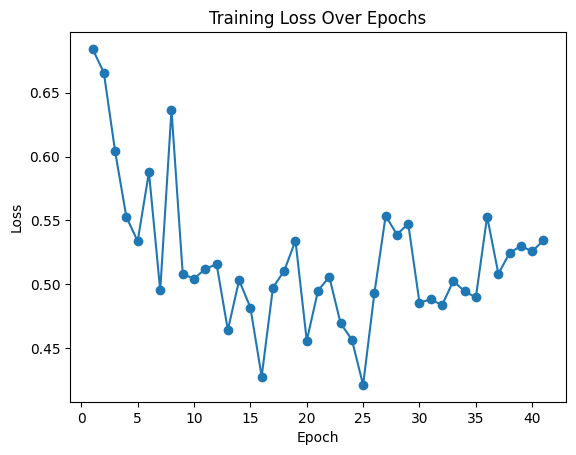

Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0000, 0.0000, 0.0492, 0.0203, 0.0000, 0.0000, 0.0694, 0.1162,
         0.0000, 0.0468, 0.2250, 0.1462, 0.0588, 0.5298, 0.0463, 0.0283, 0.1852,
         0.1930, 0.0000, 0.0000, 0.0000, 0.0124, 0.0695, 0.1361, 0.0387, 0.1115,
         0.0000, 0.0354]]), norm 1.3451110589812743e-06
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0000, 0.0000, 0.0124, 0.0000, 0.0000, 0.0322, 0.0080, 0.1522,
         0.0584, 0.0384, 0.5766, 0.1665, 0.1688, 0.6509, 0.0736, 0.1449, 0.4452,
         0.1294, 0.0660, 0.1473, 0.0519, 0.0000, 0.0465, 0.0512, 0.0000, 0.0653,
         0.0000, 0.0000]]), norm 1.3451110589812743e-06
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0327, 0.0578, 0.0413, 0.0000, 0.0283, 0.0000, 0.0000, 0.0000, 0.1480,
         0.0228, 0.0759, 0.4474, 0.0043, 0.0735, 0.4861, 0.0126, 0.0999, 0.1734,
         0.0569, 0.04

In [ ]:
name_of_experiment = "experiment_moons_05"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 31

# Convert y_train to have values 0 and 1 for binary classification
import json

y_train_binary = (y_train > 0).float()
y_test_binary = (y_test > 0).float()

def save_meshgrid_and_data(xx, yy, Z, X, y, filename=f"./data_runs/{name_of_experiment}/meshgrid_data_paper.json"):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        filename (str): Name of the JSON file.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X, y, model, epoch, normalization):
    x_min, x_max = X[:, 0].min(), X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min(), X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                         np.arange(y_min, y_max, 0.2))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    Z = np.empty(grid_tensor.shape[0])
    with torch.no_grad():
        for point in range(grid_tensor.shape[0]):
            z_value = model(grid_tensor[point], normalization)
            z_value = torch.sigmoid(z_value)
            Z[point] = z_value.item()
        
    Z = Z.reshape(xx.shape)

    # Save meshgrid and data points
    save_meshgrid_and_data(xx, yy, Z, X, y)

    # Plotting
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Spectral)
    plt.title(f'Epoch {epoch}')
    plt.savefig(f'./data_runs/{name_of_experiment}/boundary_{epoch}.png')
    plt.close()

def train(model, X_train, y_train_binary, optimizer, epoch, loss_history, normalization):
    model.train()
    epoch_loss = 0
    for data in range(X_train.shape[0]):
        optimizer.zero_grad()
        output = model(X_train[data], normalization)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/traces/trace_data_{epoch}_{data}.csv")
        #osa.save_image('data3', f'trace_data_{epoch}_{data}_paper')
        print(f'The train binary is {y_train_binary[data]}; the output binary is {output}')
        loss = criterion(output, y_train_binary[data].unsqueeze(0))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / X_train.shape[0]
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
def test(model, X_test, y_test, normalization):
    predicted_classes = []
    with torch.no_grad():
        for data in range(X_test.shape[0]):
            y_pred = model(X_test[data], normalization)
            y_pred = torch.sigmoid(y_pred)
            predicted_classes.append(y_pred.item())  # Use .item() to get the scalar value

    # Convert predicted_classes to a NumPy array for scikit-learn metrics
    predicted_classes = np.array(predicted_classes)
    y_test = y_test.numpy()  # Convert y_test to a NumPy array if it's a tensor

    # Calculate accuracy
    accuracy = accuracy_score((y_test > 0.5), (predicted_classes > 0.5))
    print(f'Accuracy: {accuracy:.4f}')
    return accuracy

interval_images = 1


# Step 4: Train the Model
model = ClassifierPhysical_NN_SHG()
optimizer = optim.Adam(model.parameters(), lr=2e-2)
criterion = nn.BCEWithLogitsLoss()#nn.MSELoss()  # Binary Cross-Entropy Loss with logits

import pandas as pd  # For saving data to CSV

# Initialize a dictionary to store power measurements
power_measurements = {}
for i in range(2*hidden_dim-1):  
    power_measurements[f"peak{i}"] = []
# Training loop with visualization and periodic measurements

loss_history = []


for epoch in range(epochs):
    train(model, X_train, y_train_binary, optimizer, epoch, loss_history, normalization)
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    
    # Stop training if the loss is below the threshold
    if avg_loss < 0.001:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break
    
    accuracy = test(model, X_test, y_test_binary, normalization)
    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'accuracy_score': accuracy
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')
    
    # Perform measurement every 10 epochs
    if (epoch + 1) % 1 == 0:
        peaks_decopling = np.ones(n_comblines)
        phases_decopling = np.zeros(n_comblines)
        channels_decopling = np.ones(n_comblines)

        apply_waveshaper_profile(comblines, peaks_decopling, phases_decopling, channels_decopling, plot = False)
        wav, power = osa.perform_measurement_OSA(center=np.mean(comblines)/2, span=(np.max(comblines)-np.mean(comblines))+0.5, level=0.006, sensitivity = "high3", resolution = 0.02)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}.csv")
        normalization = np.max(power)
        # Store power at specified indices

        for i, index in enumerate(max_indices):
            power_measurements[f"peak{i}"].append(power[index])
        print(f"Coupling loss measurements taken at epoch {epoch + 1}")
        
# Save power measurements to a CSV file
df = pd.DataFrame([power_measurements])  # Convert dictionary to a DataFrame
df.to_csv(f'./data_runs/{name_of_experiment}/spectral_consistency.csv', index=False)
print("Power measurements saved to spectral_consistency.csv")

# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

# Plot the final decision boundary
plot_decision_boundary(X_train.numpy(), y_train.numpy(), model, epoch, normalization)



In [9]:
# Plot the final decision boundary
plot_decision_boundary(X_train.numpy(), y_train.numpy(), model, 1000, normalization)

Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0044, 0.0217, 0.0259, 0.0182, 0.1051, 0.0000, 0.0908, 0.0794,
         0.0038, 0.0291, 0.2580, 0.1125, 0.1930, 0.5292, 0.0869, 0.0981, 0.2273,
         0.0431, 0.0316, 0.0000, 0.0009, 0.0000, 0.1285, 0.0448, 0.0000, 0.0336,
         0.0533, 0.0078]]), norm 1.3451110589812743e-06
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0000, 0.0000, 0.0202, 0.0000, 0.0637, 0.0800, 0.0039, 0.0854, 0.1276,
         0.0576, 0.0758, 0.5282, 0.1439, 0.2016, 0.6710, 0.0928, 0.1066, 0.3838,
         0.1103, 0.1225, 0.1542, 0.0375, 0.0000, 0.0512, 0.1171, 0.0000, 0.0566,
         0.0000, 0.0261]]), norm 1.3451110589812743e-06
Applying profile...   success
Sweep complete.
The output from the pat is tensor([[0.0020, 0.0600, 0.0000, 0.0423, 0.0780, 0.0672, 0.0000, 0.0054, 0.1034,
         0.0575, 0.1350, 0.4841, 0.0828, 0.0922, 0.4686, 0.0621, 0.0136, 0.1981,
         0.0524, 0.08

In [10]:
!git add .
!git commit -m "working"
!git push origin main

[main 0823d19] working
 3 files changed, 23451 insertions(+), 10272 deletions(-)


To https://github.com/daalopezm/Physical_NN_SHG.git
   eb7d358..0823d19  main -> main


C:\Users\ws-server\AppData\Local\Temp\ipykernel_2552\1405627846.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


model_checkpoint0.pth: Loss = 0.6843182512692043
model_checkpoint1.pth: Loss = 0.6657133894307273
model_checkpoint2.pth: Loss = 0.6040357932448387
model_checkpoint3.pth: Loss = 0.5526268348097801
model_checkpoint4.pth: Loss = 0.5337293277893748
model_checkpoint5.pth: Loss = 0.5877551295927592
model_checkpoint6.pth: Loss = 0.4952489400548594
model_checkpoint7.pth: Loss = 0.6365842988448484
model_checkpoint8.pth: Loss = 0.507913617257561
model_checkpoint9.pth: Loss = 0.5044350011008126
model_checkpoint10.pth: Loss = 0.5119813131434577
model_checkpoint11.pth: Loss = 0.5157329944627626
model_checkpoint12.pth: Loss = 0.46417233901364463
model_checkpoint13.pth: Loss = 0.5031783773430756
model_checkpoint14.pth: Loss = 0.4817121646233967
model_checkpoint15.pth: Loss = 0.4276727334729263
model_checkpoint16.pth: Loss = 0.4973329032106059
model_checkpoint17.pth: Loss = 0.5105318816644805
model_checkpoint18.pth: Loss = 0.5341317155531474
model_checkpoint19.pth: Loss = 0.4557592651673726
model_chec

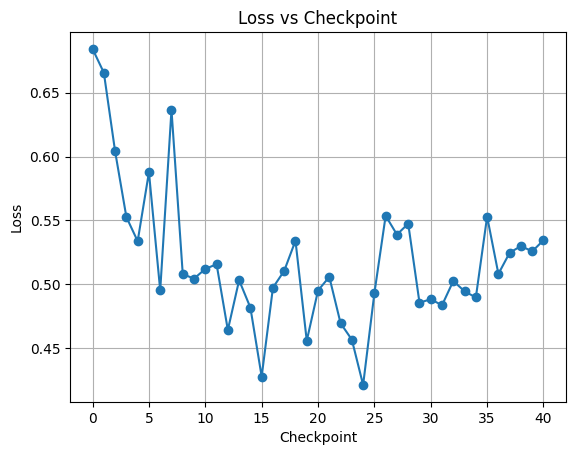

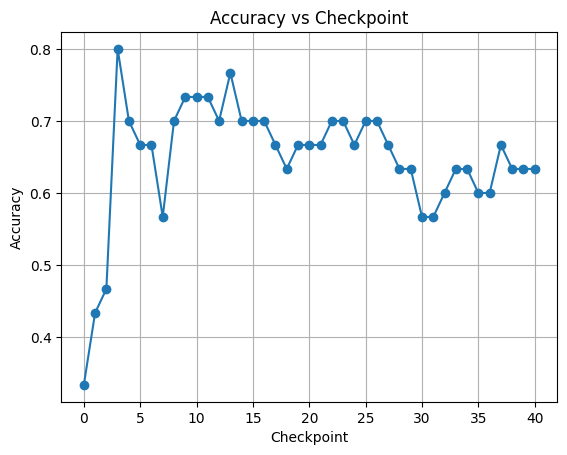

In [11]:
import torch
import os

# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
losses = []
accuracies = []

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)
        
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'loss' in checkpoint:
            loss = checkpoint['loss']
            losses.append((filename, loss))
        else:
            print(f"Loss not found in {filename}")

        if 'accuracy_score' in checkpoint:
            accuracy = checkpoint['accuracy_score']
            accuracies.append((filename, accuracy))
        else:
            print(f"Accuracy not found in {filename}")

# Print the extracted losses
for filename, loss in losses:
    print(f"{filename}: Loss = {loss}")

# Print the extracted losses
for filename, accuracy in accuracies:
    print(f"{filename}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt

# Extracting just the loss values for plotting
loss_values = [loss for _, loss in losses]
plt.plot(loss_values, marker='o')
plt.title("Loss vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Extracting just the loss values for plotting
accuracy_values = [accuracy for _, accuracy in accuracies]
plt.plot(accuracy_values, marker='o')
plt.title("Accuracy vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [12]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed
